# Upload Data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving uc3m-licitaciones-contratos-mayores-2023.xlsx to uc3m-licitaciones-contratos-mayores-2023.xlsx


In [ ]:
import os
os.listdir()

['.config', 'licitaciones_contratos_mayores.ipynb', 'sample_data']

In [ ]:
import pandas as pd

licitaciones = pd.read_excel("uc3m-licitaciones-contratos-mayores-2023.xlsx")

licitaciones.head()

,identificador,link_licitacion,fecha_actualizacion,vigente_o_anulada_o_archivada,primera_publicacion,estado,numero_de_expediente,objeto_del_contrato,identificador_unico_ted,valor_estimado_del_contrato,...,ofertas_excluidas_por_anormalmente_bajas_por_licitacion_o_lote,numero_del_contrato_licitacion_o_lote,fecha_formalizacion_del_contrato_licitacion_o_lote,fecha_entrada_en_vigor_del_contrato_de_licitacion_o_lote,adjudicatario_licitacion_o_lote,tipo_de_identificador_de_adjudicatario_por_licitacion_o_lote,identificador_adjudicatario_de_la_licitacion_o_lote,el_adjudicatario_es_o_no_pyme_de_la_licitacion_o_lote,importe_adjudicacion_sin_impuestos_licitacion_o_lote,importe_adjudicacion_con_impuestos_licitacion_o_lote
0,13080496,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-26 09:00:00.000,VIGENTE,2023-07-13,Resuelta,2023/0003504,Servicio de mantenimiento de climatización y o...,NaN,3216915.32,...,NaN,2023-111,2023-12-20,NaT,"FULTON SERVICIOS INTEGRALES, S.A.",NIF,A97152094,0.0,1279289.12,1547939.83
1,13736382,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-20 12:27:32.157,VIGENTE,2023-11-17,Resuelta,2023/0007532,Suministro de ampliación switches top pf rack ...,NaN,79500.00,...,NaN,2023-110,2023-12-19,NaT,NTT SPAIN INTELLIGENT TECHNOLOGIES AND SERVICES,NIF,B62174842,0.0,78629.74,95141.99
2,12810837,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-19 09:23:26.294,VIGENTE,2023-05-26,Resuelta,2023/0003287,6G-CLARION A5: Diseñar protocolos de descubrim...,NaN,188306.25,...,NaN,2023-92,2023-10-24,NaT,UNIVERSIDAD DE ALCALÁ,NIF,Q2818018J,0.0,155625.00,188306.25
3,12681766,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-18 16:36:00.046,VIGENTE,2023-05-05,Resuelta,2023/0002878,Obra de electrificación de aulas en el Campus ...,NaN,88697.78,...,NaN,2023-76,2023-07-03,NaT,"INSTAVI MADRID, S.L.U.",NIF,B65112765,0.0,73008.40,88340.16
4,13908399,https://contrataciondelestado.es/wps/poc?uri=d...,2023-12-18 09:45:05.063,VIGENTE,2023-12-12,Resuelta,2023/0007170,Servicio de mantenimiento del microscopio elec...,NaN,50012.64,...,NaN,2023-109,2023-12-15,NaT,FEI Europe BV Sucursal en Espana,OTROS,W0032378B,0.0,25006.32,30257.65


# Inspect Structure

In [ ]:
print("Shape:", licitaciones.shape)
print("\nColumns:")
print(licitaciones.columns)

print("\nMissing values:")
print(licitaciones.isnull().sum())

Shape: (132, 146)

Columns:
Index(['identificador', 'link_licitacion', 'fecha_actualizacion',
       'vigente_o_anulada_o_archivada', 'primera_publicacion', 'estado',
       'numero_de_expediente', 'objeto_del_contrato',
       'identificador_unico_ted', 'valor_estimado_del_contrato',
       ...
       'ofertas_excluidas_por_anormalmente_bajas_por_licitacion_o_lote',
       'numero_del_contrato_licitacion_o_lote',
       'fecha_formalizacion_del_contrato_licitacion_o_lote',
       'fecha_entrada_en_vigor_del_contrato_de_licitacion_o_lote',
       'adjudicatario_licitacion_o_lote',
       'tipo_de_identificador_de_adjudicatario_por_licitacion_o_lote',
       'identificador_adjudicatario_de_la_licitacion_o_lote',
       'el_adjudicatario_es_o_no_pyme_de_la_licitacion_o_lote',
       'importe_adjudicacion_sin_impuestos_licitacion_o_lote',
       'importe_adjudicacion_con_impuestos_licitacion_o_lote'],
      dtype='object', length=146)

Missing values:
identificador                        

In [ ]:
licitaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Columns: 146 entries, identificador to importe_adjudicacion_con_impuestos_licitacion_o_lote
dtypes: datetime64[ns](6), float64(91), int64(8), object(41)
memory usage: 150.7+ KB


# Relevant Columns

In [ ]:
cols_keep = [
    "estado",
    "fecha_formalizacion_del_contrato_licitacion_o_lote",
    "importe_adjudicacion_sin_impuestos_licitacion_o_lote"
]

licit_clean = licitaciones[cols_keep].copy()

licit_clean.head()

,estado,fecha_formalizacion_del_contrato_licitacion_o_lote,importe_adjudicacion_sin_impuestos_licitacion_o_lote
0,Resuelta,2023-12-20,1279289.12
1,Resuelta,2023-12-19,78629.74
2,Resuelta,2023-10-24,155625.00
3,Resuelta,2023-07-03,73008.40
4,Resuelta,2023-12-15,25006.32


In [ ]:
licit_clean["estado"].value_counts()

,count
estado,
Resuelta,132


# Remove Missing Monetary Values

In [ ]:
licit_clean = licit_clean.dropna(
    subset=["importe_adjudicacion_sin_impuestos_licitacion_o_lote"]
)

licit_clean.shape

(126, 3)

# Check Year Consistency

In [ ]:
licit_clean["fecha_formalizacion_del_contrato_licitacion_o_lote"] = pd.to_datetime(
    licit_clean["fecha_formalizacion_del_contrato_licitacion_o_lote"],
    errors="coerce"
)

licit_clean["fecha_formalizacion_del_contrato_licitacion_o_lote"].dt.year.value_counts()

,count
fecha_formalizacion_del_contrato_licitacion_o_lote,
2023.0,110
2022.0,9
2021.0,2


We Use Only Contracts Formalized in 2023

In [ ]:
licit_clean = licit_clean[
    licit_clean["fecha_formalizacion_del_contrato_licitacion_o_lote"].dt.year == 2023
]

In [ ]:
licit_clean.shape

(110, 3)

# Validate Monetary Values

In [ ]:
licit_clean["importe_adjudicacion_sin_impuestos_licitacion_o_lote"].describe()

,importe_adjudicacion_sin_impuestos_licitacion_o_lote
count,1.100000e+02
mean,2.576148e+05
std,3.633185e+05
min,0.000000e+00
25%,4.260207e+04
50%,1.466350e+05
75%,2.940000e+05
max,2.528297e+06


# Compute Total Major Spending 2023

In [ ]:
total_major_spending = licit_clean[
    "importe_adjudicacion_sin_impuestos_licitacion_o_lote"
].sum()

print("Total major contract spending (sin impuestos):", total_major_spending)

Total major contract spending (sin impuestos): 28337632.1


# Distribution of Contract Sizes

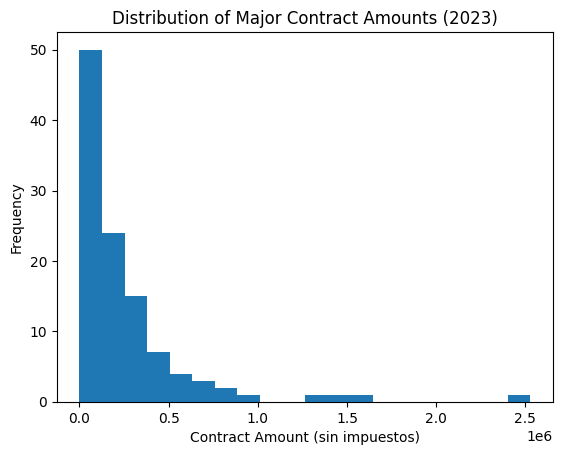

In [ ]:
import matplotlib.pyplot as plt

plt.hist(
    licit_clean["importe_adjudicacion_sin_impuestos_licitacion_o_lote"],
    bins=20
)
plt.title("Distribution of Major Contract Amounts (2023)")
plt.xlabel("Contract Amount (sin impuestos)")
plt.ylabel("Frequency")
plt.show()

# Add Index

In [ ]:
licit_clean = licit_clean.reset_index(drop=True)
licit_clean.insert(0, "contract_id", licit_clean.index + 1)

# Save Dataset

In [ ]:
licit_clean.to_csv("licitaciones_clean.csv", index=False)

In [ ]:
from google.colab import files
files.download("licitaciones_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>